[i] Using device: cpu
[i] Loading model from malware_classifier.pth...
[i] Extracting features from penultimate layer...
[i] Extracted features shape: (2209, 1000)
[i] Labels shape: (2209,)
[i] Reducing dimensions using TSNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2209 samples in 0.001s...
[t-SNE] Computed neighbors for 2209 samples in 0.270s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2209
[t-SNE] Computed conditional probabilities for sample 2000 / 2209
[t-SNE] Computed conditional probabilities for sample 2209 / 2209
[t-SNE] Mean sigma: 0.952132
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.346581
[t-SNE] KL divergence after 1000 iterations: 0.728860
[i] Reduced to 2D shape: (2209, 2)

CREATING VISUALIZATIONS

[1/3] Basic decision boundaries...
[✓] Saved: decision_boundaries.png


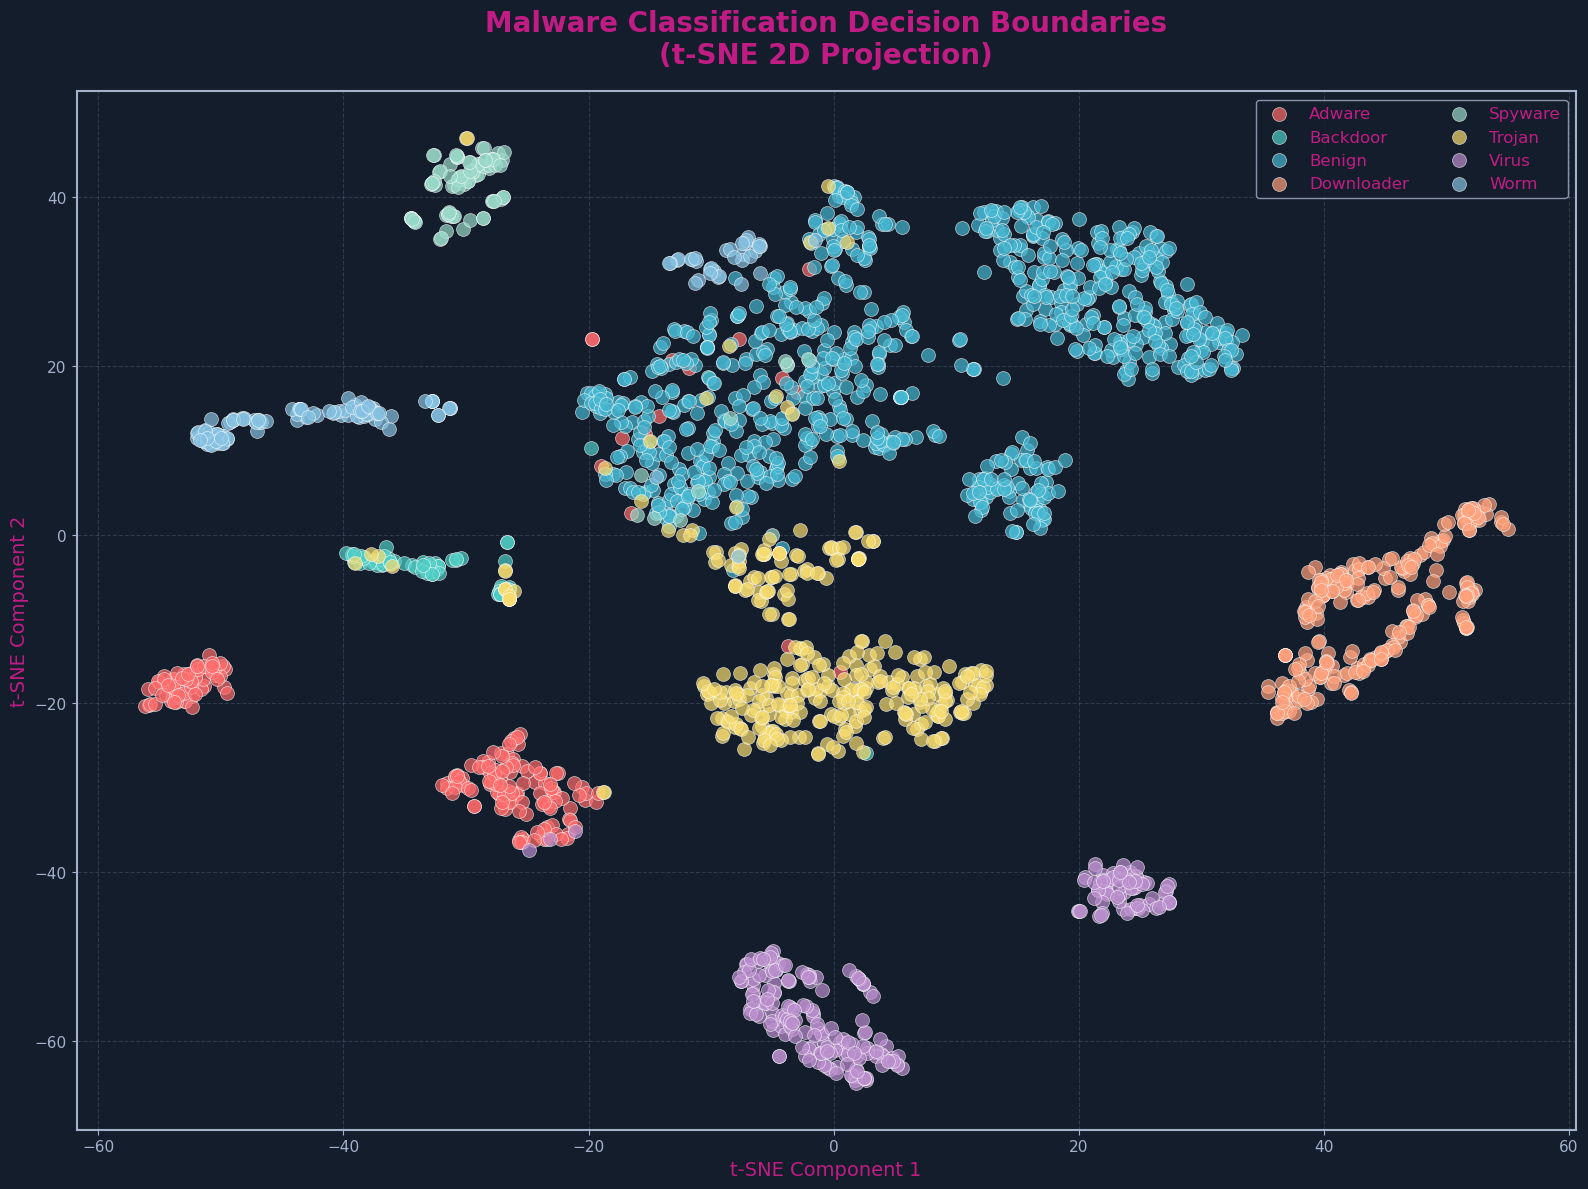


[2/3] Decision regions with density...
[✓] Saved: decision_regions_density.png


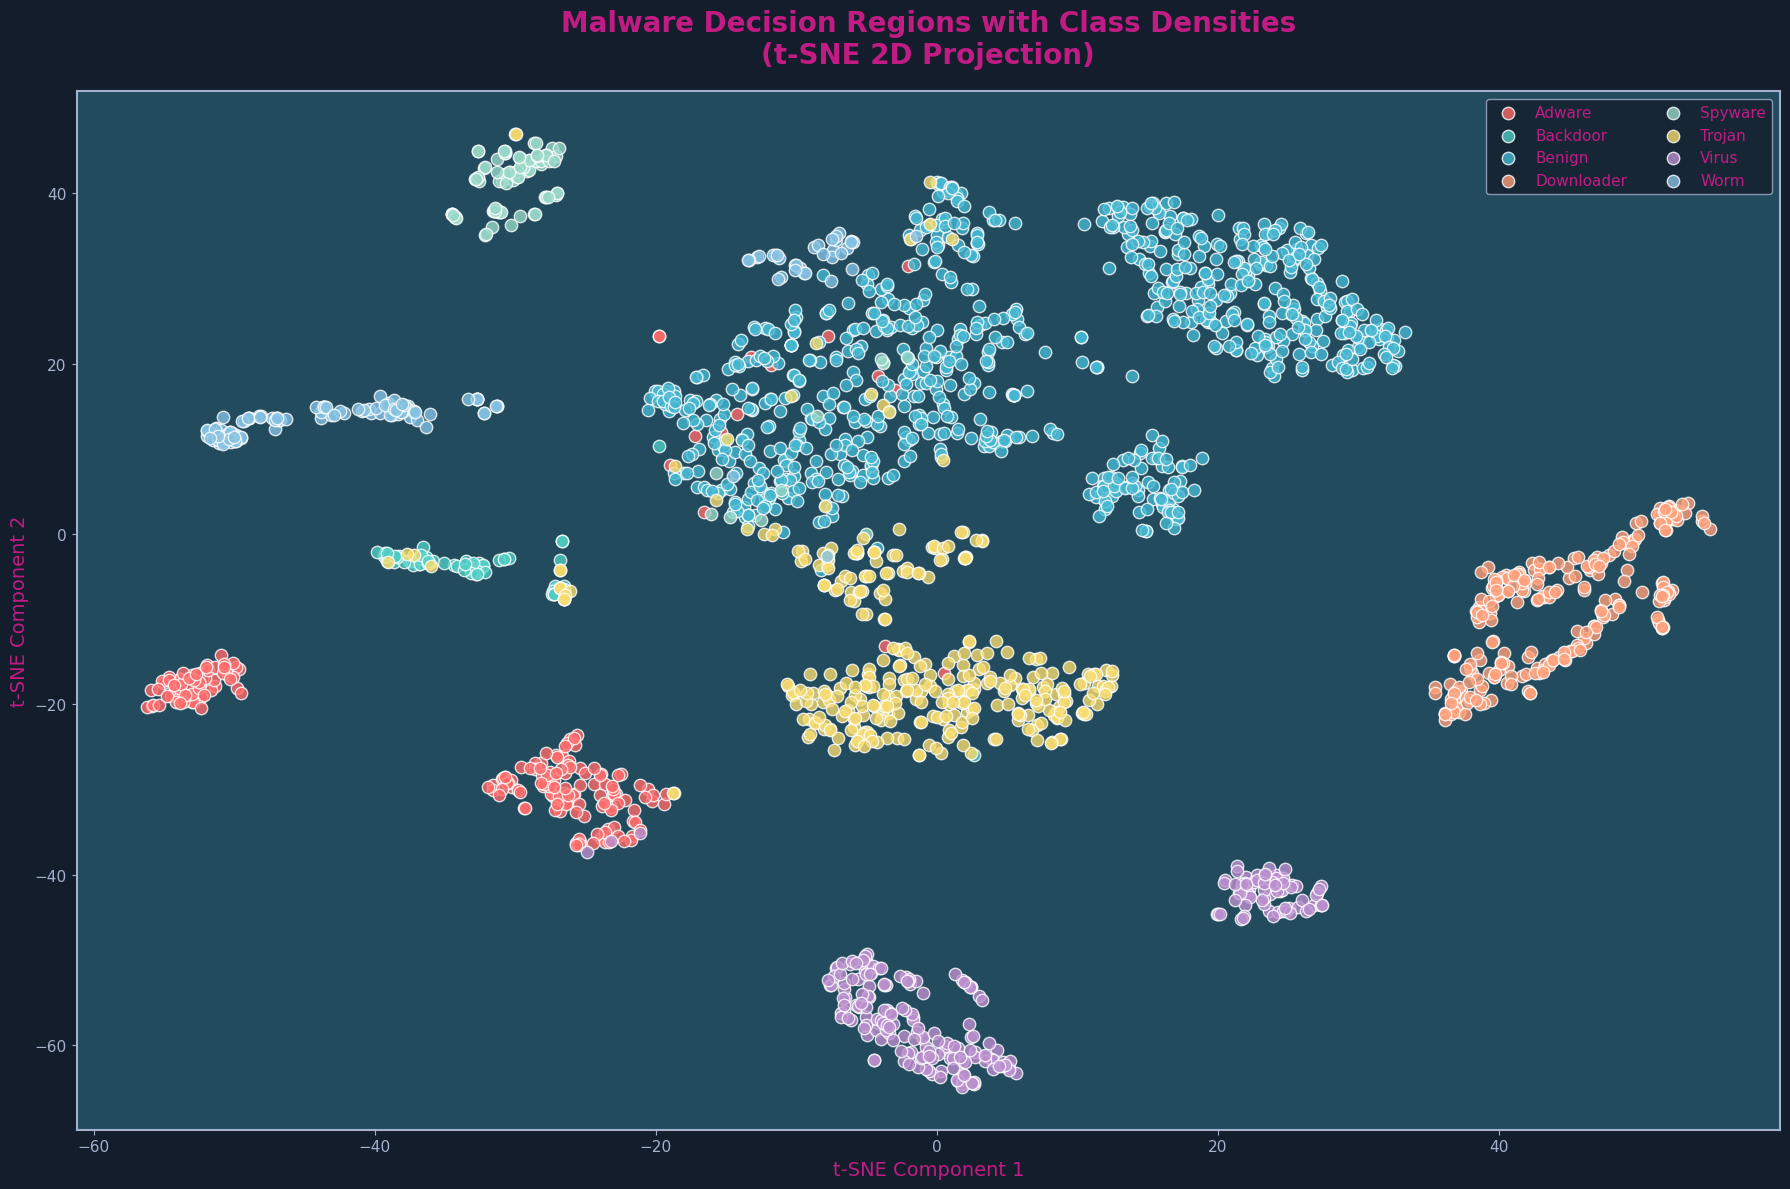


[3/3] Class boundaries with convex hulls...
[✓] Saved: decision_boundaries_hulls.png


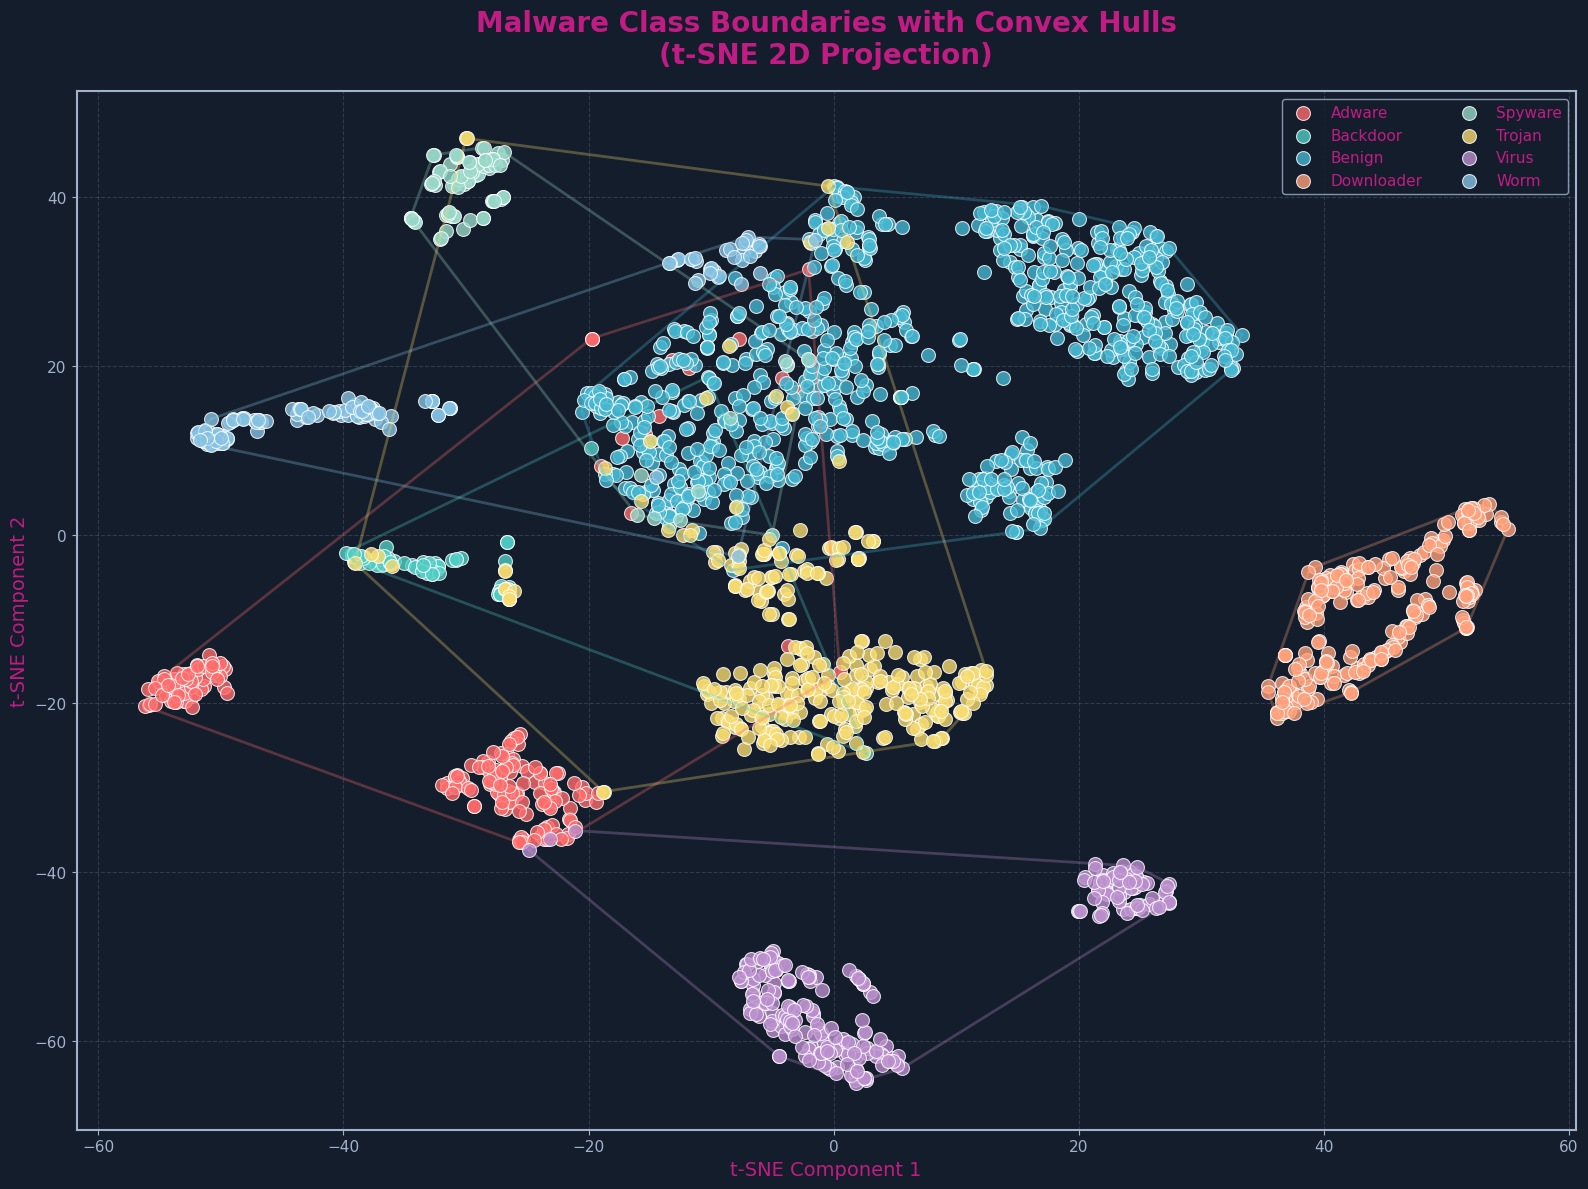


✓ ALL VISUALIZATIONS COMPLETE

Generated files:
  • decision_boundaries.png
  • decision_regions_density.png
  • decision_boundaries_hulls.png


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import seaborn as sns
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os

# ============================================
# CONFIGURATION
# ============================================
DATA_PATH = "/home/beylessen/Desktop/PFA2/Sorted"
MODEL_PATH = "malware_classifier.pth"
BATCH_SIZE = 32
N_SAMPLES_PER_CLASS = 150  # Limit samples for faster computation

# Styling
PINK = "#C11C84"
NODE_BLACK = "#141D2B"
HACKER_GREY = "#A4B1CD"

# Class names for better visualization
CLASS_NAMES = ['adware', 'backdoor', 'benign', 'downloader', 
               'spyware', 'trojan', 'virus', 'worm']

# Color palette for 8 classes
COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', 
          '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E2']

# ============================================
# LOAD MODEL (reconstruct from scratch)
# ============================================
def load_trained_model(model_path, device):
    """Reconstruct and load the trained malware classifier"""
    import torch.nn as nn
    import torchvision.models as models
    
    # Reconstruct the model architecture
    class MalwareClassifier(nn.Module):
        def __init__(self, n_classes):
            super(MalwareClassifier, self).__init__()
            self.resnet = models.resnet50(weights='DEFAULT')
            
            for param in self.resnet.parameters():
                param.requires_grad = False
            
            num_features = self.resnet.fc.in_features
            self.resnet.fc = nn.Sequential(
                nn.Linear(num_features, 1000),
                nn.ReLU(),
                nn.Linear(1000, n_classes)
            )

        def forward(self, x):
            return self.resnet(x)
        
        def extract_features(self, x):
            """Extract features from penultimate layer"""
            # Forward through ResNet backbone
            x = self.resnet.conv1(x)
            x = self.resnet.bn1(x)
            x = self.resnet.relu(x)
            x = self.resnet.maxpool(x)
            
            x = self.resnet.layer1(x)
            x = self.resnet.layer2(x)
            x = self.resnet.layer3(x)
            x = self.resnet.layer4(x)
            
            x = self.resnet.avgpool(x)
            x = torch.flatten(x, 1)
            
            # Pass through first layer of custom classifier (penultimate)
            x = self.resnet.fc[0](x)  # Linear: 2048 -> 1000
            x = self.resnet.fc[1](x)  # ReLU
            
            return x
    
    # Load the scripted model to get state dict
    scripted_model = torch.jit.load(model_path, map_location=device)
    
    # Create new model and load weights
    model = MalwareClassifier(n_classes=8)
    model.load_state_dict(scripted_model.state_dict())
    model.to(device)
    model.eval()
    
    return model

# ============================================
# EXTRACT FEATURES
# ============================================
def extract_features(model, data_loader, device, max_samples=None):
    """
    Extract feature representations from the penultimate layer
    (before final classification layer)
    """
    features = []
    labels = []
    
    model.eval()
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(data_loader):
            inputs = inputs.to(device)
            
            # Extract features using the model's method
            x = model.extract_features(inputs)
            
            features.append(x.cpu().numpy())
            labels.append(targets.numpy())
            
            if max_samples and batch_idx * BATCH_SIZE >= max_samples:
                break
    
    features = np.vstack(features)
    labels = np.concatenate(labels)
    
    return features, labels

# ============================================
# DIMENSIONALITY REDUCTION
# ============================================
def reduce_dimensions(features, method='tsne'):
    """
    Reduce high-dimensional features to 2D
    
    Args:
        features: High-dimensional feature vectors
        method: 'tsne' or 'pca'
    """
    print(f"[i] Reducing dimensions using {method.upper()}...")
    
    if method == 'tsne':
        # First reduce to 50D with PCA (faster t-SNE)
        pca = PCA(n_components=50)
        features_pca = pca.fit_transform(features)
        
        # Then apply t-SNE
        tsne = TSNE(n_components=2, random_state=42, perplexity=30, 
                    max_iter=1000, verbose=1)
        features_2d = tsne.fit_transform(features_pca)
        
    elif method == 'pca':
        pca = PCA(n_components=2)
        features_2d = pca.fit_transform(features)
        print(f"[i] Explained variance: {sum(pca.explained_variance_ratio_):.2%}")
    
    return features_2d

# ============================================
# DECISION BOUNDARY VISUALIZATION
# ============================================
def plot_decision_boundaries(features_2d, labels, class_names, colors):
    """
    Create a beautiful decision boundary visualization
    """
    fig, ax = plt.subplots(figsize=(16, 12), facecolor=NODE_BLACK)
    
    # Plot each class
    for class_idx in range(len(class_names)):
        mask = labels == class_idx
        class_points = features_2d[mask]
        
        ax.scatter(
            class_points[:, 0], 
            class_points[:, 1],
            c=colors[class_idx],
            label=class_names[class_idx].capitalize(),
            alpha=0.7,
            s=100,
            edgecolors='white',
            linewidth=0.5
        )
    
    # Styling
    ax.set_facecolor(NODE_BLACK)
    ax.set_title(
        'Malware Classification Decision Boundaries\n(t-SNE 2D Projection)',
        color=PINK,
        fontsize=20,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('t-SNE Component 1', color=PINK, fontsize=14)
    ax.set_ylabel('t-SNE Component 2', color=PINK, fontsize=14)
    
    # Grid
    ax.grid(True, alpha=0.2, color=HACKER_GREY, linestyle='--')
    
    # Spines
    for spine in ax.spines.values():
        spine.set_color(HACKER_GREY)
        spine.set_linewidth(1.5)
    
    # Ticks
    ax.tick_params(colors=HACKER_GREY, labelsize=11)
    
    # Legend
    legend = ax.legend(
        loc='upper right',
        fontsize=12,
        frameon=True,
        facecolor=NODE_BLACK,
        edgecolor=HACKER_GREY,
        ncol=2
    )
    plt.setp(legend.get_texts(), color=PINK)
    
    plt.tight_layout()
    plt.savefig('decision_boundaries.png', dpi=300, facecolor=NODE_BLACK)
    print("[✓] Saved: decision_boundaries.png")
    plt.show()

# ============================================
# DENSITY-BASED DECISION BOUNDARY
# ============================================
def plot_decision_regions_with_density(features_2d, labels, class_names, colors):
    """
    Create decision regions using density estimation
    """
    from scipy.stats import gaussian_kde
    from matplotlib.colors import ListedColormap
    
    fig, ax = plt.subplots(figsize=(18, 12), facecolor=NODE_BLACK)
    
    # Create mesh grid
    x_min, x_max = features_2d[:, 0].min() - 5, features_2d[:, 0].max() + 5
    y_min, y_max = features_2d[:, 1].min() - 5, features_2d[:, 1].max() + 5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    
    # Calculate density for each class
    Z = np.zeros(xx.shape)
    
    for class_idx in range(len(class_names)):
        mask = labels == class_idx
        class_points = features_2d[mask]
        
        if len(class_points) > 3:  # Need enough points for KDE
            # Kernel density estimation
            kde = gaussian_kde(class_points.T)
            positions = np.vstack([xx.ravel(), yy.ravel()])
            density = kde(positions).reshape(xx.shape)
            
            # Assign class where it has highest density
            Z = np.where(density > Z, class_idx, Z)
    
    # Plot decision regions with transparency
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap([c + '40' for c in colors])  # Add alpha
    ax.contourf(xx, yy, Z, levels=len(class_names)-1, cmap=cmap, alpha=0.3)
    
    # Plot decision boundaries
    ax.contour(xx, yy, Z, levels=len(class_names)-1, colors='white', 
               linewidths=1.5, alpha=0.4)
    
    # Plot actual points
    for class_idx in range(len(class_names)):
        mask = labels == class_idx
        class_points = features_2d[mask]
        
        ax.scatter(
            class_points[:, 0],
            class_points[:, 1],
            c=colors[class_idx],
            label=class_names[class_idx].capitalize(),
            alpha=0.8,
            s=80,
            edgecolors='white',
            linewidth=1
        )
    
    # Styling
    ax.set_facecolor(NODE_BLACK)
    ax.set_title(
        'Malware Decision Regions with Class Densities\n(t-SNE 2D Projection)',
        color=PINK,
        fontsize=20,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('t-SNE Component 1', color=PINK, fontsize=14)
    ax.set_ylabel('t-SNE Component 2', color=PINK, fontsize=14)
    
    # Spines
    for spine in ax.spines.values():
        spine.set_color(HACKER_GREY)
        spine.set_linewidth(1.5)
    
    # Ticks
    ax.tick_params(colors=HACKER_GREY, labelsize=11)
    
    # Legend
    legend = ax.legend(
        loc='upper right',
        fontsize=11,
        frameon=True,
        facecolor=NODE_BLACK,
        edgecolor=HACKER_GREY,
        ncol=2
    )
    plt.setp(legend.get_texts(), color=PINK)
    
    plt.tight_layout()
    plt.savefig('decision_regions_density.png', dpi=300, facecolor=NODE_BLACK)
    print("[✓] Saved: decision_regions_density.png")
    plt.show()

# ============================================
# CONFUSION OVERLAY
# ============================================
def plot_with_confusion_zones(features_2d, labels, model, device, class_names, colors):
    """
    Highlight regions where the model is uncertain (potential confusion zones)
    """
    fig, ax = plt.subplots(figsize=(16, 12), facecolor=NODE_BLACK)
    
    # Plot points
    for class_idx in range(len(class_names)):
        mask = labels == class_idx
        class_points = features_2d[mask]
        
        ax.scatter(
            class_points[:, 0],
            class_points[:, 1],
            c=colors[class_idx],
            label=class_names[class_idx].capitalize(),
            alpha=0.8,
            s=100,
            edgecolors='white',
            linewidth=0.8
        )
    
    # Add convex hulls for each class
    from scipy.spatial import ConvexHull
    
    for class_idx in range(len(class_names)):
        mask = labels == class_idx
        class_points = features_2d[mask]
        
        if len(class_points) >= 3:  # Need at least 3 points
            try:
                hull = ConvexHull(class_points)
                for simplex in hull.simplices:
                    ax.plot(
                        class_points[simplex, 0],
                        class_points[simplex, 1],
                        color=colors[class_idx],
                        alpha=0.3,
                        linewidth=2
                    )
            except:
                pass  # Skip if hull computation fails
    
    # Styling
    ax.set_facecolor(NODE_BLACK)
    ax.set_title(
        'Malware Class Boundaries with Convex Hulls\n(t-SNE 2D Projection)',
        color=PINK,
        fontsize=20,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('t-SNE Component 1', color=PINK, fontsize=14)
    ax.set_ylabel('t-SNE Component 2', color=PINK, fontsize=14)
    
    ax.grid(True, alpha=0.2, color=HACKER_GREY, linestyle='--')
    
    for spine in ax.spines.values():
        spine.set_color(HACKER_GREY)
        spine.set_linewidth(1.5)
    
    ax.tick_params(colors=HACKER_GREY, labelsize=11)
    
    legend = ax.legend(
        loc='upper right',
        fontsize=11,
        frameon=True,
        facecolor=NODE_BLACK,
        edgecolor=HACKER_GREY,
        ncol=2
    )
    plt.setp(legend.get_texts(), color=PINK)
    
    plt.tight_layout()
    plt.savefig('decision_boundaries_hulls.png', dpi=300, facecolor=NODE_BLACK)
    print("[✓] Saved: decision_boundaries_hulls.png")
    plt.show()

# ============================================
# MAIN EXECUTION
# ============================================
def main():
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[i] Using device: {device}")
    
    # Load model
    print(f"[i] Loading model from {MODEL_PATH}...")
    model = load_trained_model(MODEL_PATH, device)
    
    # Prepare data loader
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    test_dataset = datasets.ImageFolder(
        os.path.join(DATA_PATH, "test"),
        transform=transform
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4
    )
    
    # Extract features
    print("[i] Extracting features from penultimate layer...")
    features, labels = extract_features(model, test_loader, device)
    print(f"[i] Extracted features shape: {features.shape}")
    print(f"[i] Labels shape: {labels.shape}")
    
    # Reduce dimensions
    features_2d = reduce_dimensions(features, method='tsne')
    print(f"[i] Reduced to 2D shape: {features_2d.shape}")
    
    # Create visualizations
    print("\n" + "="*50)
    print("CREATING VISUALIZATIONS")
    print("="*50 + "\n")
    
    print("[1/3] Basic decision boundaries...")
    plot_decision_boundaries(features_2d, labels, CLASS_NAMES, COLORS)
    
    print("\n[2/3] Decision regions with density...")
    plot_decision_regions_with_density(features_2d, labels, CLASS_NAMES, COLORS)
    
    print("\n[3/3] Class boundaries with convex hulls...")
    plot_with_confusion_zones(features_2d, labels, model, device, CLASS_NAMES, COLORS)
    
    print("\n" + "="*50)
    print("✓ ALL VISUALIZATIONS COMPLETE")
    print("="*50)
    print("\nGenerated files:")
    print("  • decision_boundaries.png")
    print("  • decision_regions_density.png")
    print("  • decision_boundaries_hulls.png")

if __name__ == "__main__":
    main()